# Challenge 8 — Series Temporales II: Forescasting

**Nombre:** Abigail Chirinos Espejel
**Clase:** Series Temporales II: Forecasting  

**Objetivo**  
Construir y comparar diferentes modelos de pronóstico utilizando una separación temporal válida

**Challenge:**

**¿Qué método utilizaríamos para pronosticar las ventas de los próximos meses?**

Para este ejercicio se utiliza `ventas_forecast.csv`, que contiene ventas mensuales.

## 1. Cargar los datos

Este archivo ya está preparado para forecasting mensual. Tiene 48 meses de información, por lo que sí podemos reservar los últimos 12 meses como test, tal como pide la actividad.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ventas_forecast.csv")

df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha")

serie = df.set_index("fecha")["ventas"].asfreq("MS")

print("Observaciones:", len(serie))
print("Primera fecha:", serie.index.min())
print("Última fecha:", serie.index.max())

serie.head()

Observaciones: 48
Primera fecha: 2022-09-01 00:00:00
Última fecha: 2026-08-01 00:00:00


fecha
2022-09-01    14350.0
2022-10-01    14011.0
2022-11-01    15197.0
2022-12-01    15340.0
2023-01-01    16389.0
Freq: MS, Name: ventas, dtype: float64

## 2. Train / Test temporal

In [2]:
test_size = 12

train = serie.iloc[:-test_size]
test = serie.iloc[-test_size:]

print("Train:", len(train), "meses")
print("Test:", len(test), "meses")
print("Último mes de train:", train.index[-1])
print("Primer mes de test:", test.index[0])

Train: 36 meses
Test: 12 meses
Último mes de train: 2025-08-01 00:00:00
Primer mes de test: 2025-09-01 00:00:00


No se utiliza un split aleatorio. El modelo aprende con los meses anteriores y se evalúa en los 12 meses posteriores.

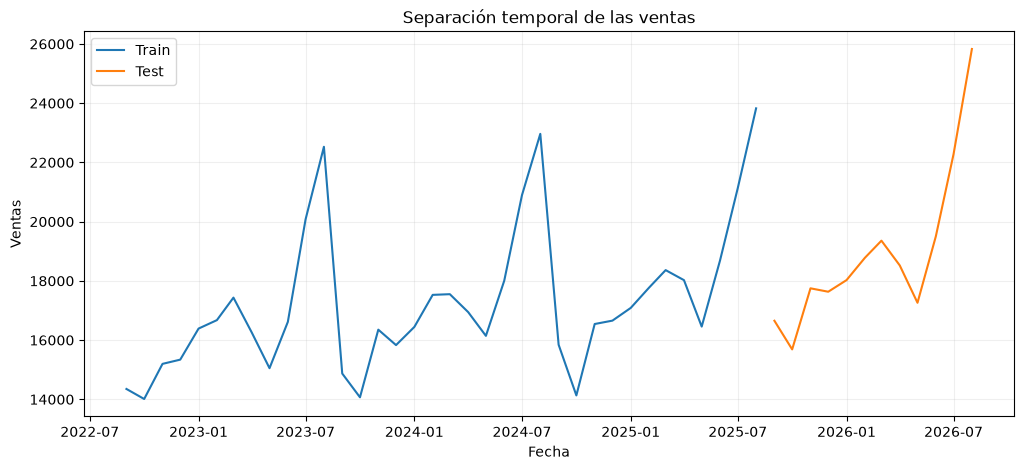

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Separación temporal de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 3. Naive Forecast

In [4]:
pred_naive = np.repeat(train.iloc[-1], len(test))
pred_naive[:5]

array([23825., 23825., 23825., 23825., 23825.])

El modelo Naive usa el último valor observado como pronóstico para todos los meses del test.

## 4. Seasonal Naive

In [5]:
# Repetimos los últimos 12 meses
pred_seasonal_naive = train.iloc[-12:].values

pred_seasonal_naive[:5]

array([15843., 14132., 16543., 16657., 17087.])

Como los datos son mensuales, usamos una estacionalidad de 12 meses para representar un posible patrón anual.

## 5. Holt

In [6]:
from statsmodels.tsa.holtwinters import Holt

modelo_holt = Holt(train).fit()
pred_holt = modelo_holt.forecast(len(test))

pred_holt.head()

TypeError: initialization_method must be a string

Holt modela principalmente el nivel y la tendencia de la serie.

## 6. Holt-Winters

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

modelo_hw = ExponentialSmoothing(train,trend="add",seasonal="add",seasonal_periods=12).fit()
pred_hw = modelo_hw.forecast(len(test))
pred_hw.head()

2025-09-01    16238.205421
2025-10-01    15287.112280
2025-11-01    17247.332884
2025-12-01    17159.317232
2026-01-01    17857.016587
Freq: MS, dtype: float64

Holt-Winters incorpora tendencia y estacionalidad anual de 12 meses.

## 7. ARIMA — modelo bonus

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

modelo_arima = ARIMA(train, order=(1, 1, 1)).fit()
pred_arima = modelo_arima.forecast(len(test))

pred_arima.head()

2025-09-01    23261.912790
2025-10-01    22915.166996
2025-11-01    22701.642973
2025-12-01    22570.156134
2026-01-01    22489.187312
Freq: MS, Name: predicted_mean, dtype: float64

ARIMA se incluye como modelo adicional para comparar su desempeño con los modelos anteriores.

## 8. Evaluación

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluar(real, pred):
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    return mae, rmse, mape

modelos = {"Naive": pred_naive,"Seasonal Naive": pred_seasonal_naive,"Holt": pred_holt,"Holt-Winters": pred_hw,"ARIMA": pred_arima}
resultados = []
for nombre, pred in modelos.items():
    mae, rmse, mape = evaluar(test.values, np.asarray(pred))
    resultados.append([nombre, mae, rmse, mape])

resultados = pd.DataFrame(resultados,columns=["Modelo", "MAE", "RMSE", "MAPE"])
resultados.sort_values("MAE")

,Modelo,MAE,RMSE,MAPE
3,Holt-Winters,443.899631,560.180173,2.238549
1,Seasonal Naive,1062.583333,1127.239290,5.601940
4,ARIMA,4192.702500,4554.283614,23.396838
0,Naive,5219.583333,5540.294389,29.164510
2,Holt,5362.618521,5684.256256,29.969011


## 9. Modelo con menor MAE

In [ ]:
modelo_ganador = resultados.loc[resultados["MAE"].idxmin(), "Modelo"]

print("Modelo con menor MAE:", modelo_ganador)

Modelo con menor MAE: Holt-Winters


## 10. Gráfica del pronóstico ganador

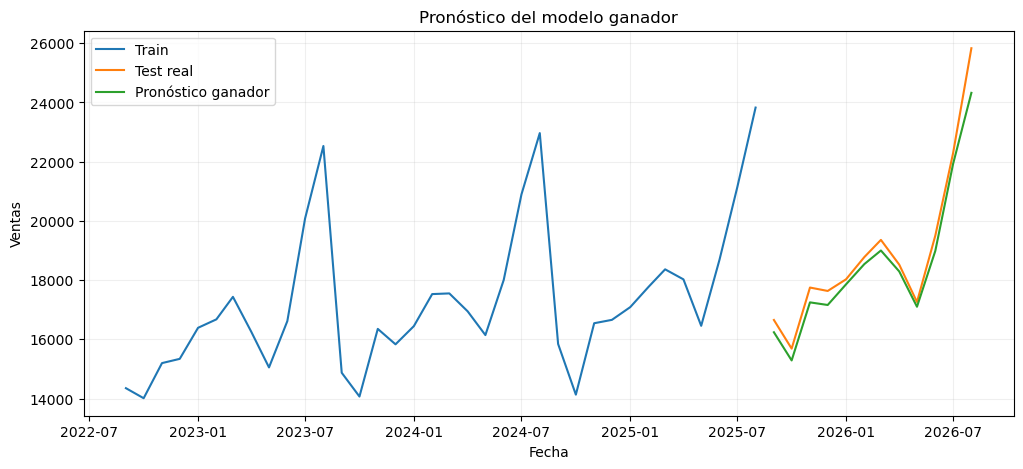

In [ ]:
predicciones = modelos[modelo_ganador]
plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test real")
plt.plot(test.index, predicciones, label="Pronóstico ganador")
plt.title("Pronóstico del modelo ganador")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 11. Residuos

Promedio de residuos: 443.899631343927
Mínimo: 159.91981766098615
Máximo: 1506.8734297423543


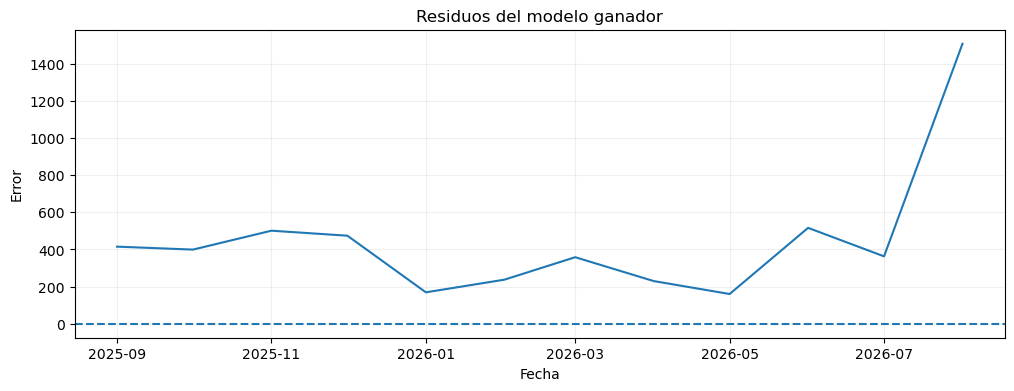

In [ ]:
residuos = test.values - np.asarray(predicciones)

print("Promedio de residuos:", residuos.mean())
print("Mínimo:", residuos.min())
print("Máximo:", residuos.max())
plt.figure(figsize=(12, 4))
plt.plot(test.index, residuos)
plt.axhline(0, linestyle="--")
plt.title("Residuos del modelo ganador")
plt.xlabel("Fecha")
plt.ylabel("Error")
plt.grid(alpha=0.2)
plt.show()

### Interpretación

- Residuo positivo: el pronóstico quedó por debajo de la venta real.
- Residuo negativo: el pronóstico quedó por encima de la venta real.
- Si aparecen patrones claros en los residuos, puede haber información temporal que el modelo no está capturando.


# Reflexión final

1. **¿Cuál modelo tuvo menor MAE?**  
   Se revisa la tabla de métricas y se identifica el menor valor.

2. **¿Cuál tuvo menor RMSE?**  
   Se compara la columna RMSE. Este indicador da más peso a errores grandes.

3. **¿Son el mismo?**  
   Se revisan ambos resultados porque pueden ser diferentes.

4. **¿Seasonal Naive fue competitivo?**  
   Se compara con los otros modelos para saber si repetir los últimos 12 meses fue una estrategia razonable.

5. **¿El modelo más complejo fue el mejor?**  
   No necesariamente. El resultado se determina por las métricas obtenidas en el test.

6. **¿Qué modelo utilizarías?**  
   Para este ejercicio se considera principalmente el desempeño en el periodo de test, junto con los residuos y la facilidad de interpretación.


## Conclusión

Se compararon cinco métodos utilizando una separación temporal de 36 meses para entrenamiento y 12 meses para prueba. Esto permite evaluar los modelos respetando el orden temporal de los datos. La tabla de MAE, RMSE y MAPE muestra las diferencias de desempeño. También se revisó el pronóstico del modelo con menor MAE y sus residuos. La elección final se basa en los resultados obtenidos en el periodo de prueba y no solamente en la complejidad del modelo.
